# Introduction

This tutorial requires ipykernel and Jupyter Notebooks. It covers the basics of the ``pyFiberPhotometry`` package for photometry data processing, handling, and analysis.

# Setup

First we need to import the necessary packages. If you have trouble importing any of the ``pyFiberPhotometry`` modules check to make sure your enviroment is active in the Jupyter Notebook and all dependencies are install properly (see the [Installation]() guide on the docs).

In [ ]:
import numpy as np
import pandas as pd

from pyFiberPhotometry import PhotometryExperiment, PhotometryData
from pyFiberPhotometry import TDTLoader

# 1. Loading

We will begin with learning how to load data from CSV files using the package (see the [PhotometryLoader]() section of the docs for all supported formats).

## Example 1.1: Importing from CSV
The ``CSVLoader`` expects:
* the time series and both signal timepoints to be in the same CSV file
* events to being in a JSON format of event labels to lists of their timestamps

In [2]:
# import loader
from pyFiberPhotometry import CSVLoader

# initiate loader
loader = CSVLoader(
    csv='./data/example_signals.csv',
    events_json='./data/example_events.json',
    time_col='time',
    signal_col='signal',
    isosbestic_col='isosbestic',
    downsample=1,
)

# load the data
exp = loader.load()

# see its type
type(exp)

pyFiberPhotometry.core.PhotometryExperiment.PhotometryExperiment

Now let's look at the raw data of the experiment

In [3]:
# time series and timepoints
display(
    exp.raw_signal,
    exp.raw_isosbestic,
    exp.time,
)

# events in dictionary format
display(
    {k : v[:10] for k, v in exp.events.items()}
)

array([70.86427497, 70.82309907, 70.88710769, ..., 17.45882203,
       17.41476386, 17.4164074 ], shape=(40000,))

array([28.36991092, 28.40714071, 28.36294002, ...,  6.99129387,
        6.99144016,  6.96940333], shape=(40000,))

array([0.00000e+00, 5.00000e-02, 1.00000e-01, ..., 1.99985e+03,
       1.99990e+03, 1.99995e+03], shape=(40000,))

{'event': array([100.  , 124.25, 148.55, 172.85, 197.15, 221.45, 245.75, 270.05,
        294.35, 318.65]),
 'lever1': array([153.584446  , 251.92420338, 277.76570281, 297.69582068,
        323.90649461, 350.3166868 , 395.80849864, 495.33611484,
        516.06493462, 542.83560385]),
 'lever2': array([107.44309952, 129.12298927, 176.0936023 , 201.14928899,
        372.17542351, 443.96309313, 471.70330624, 568.75354131,
        615.16890504, 639.30954999]),
 'loud_noise': array([ 109.14202878,  130.65441683,  373.42514583,  570.01569723,
         616.30801448,  640.5872797 , 1153.50071786, 1175.50506804,
        1635.76628978, 1686.3073415 ]),
 'no_loud_noise': array([ 177.56438513,  202.16547915,  445.54987574,  472.94699297,
         981.28760524, 1029.62633865, 1298.20181911, 1563.93833598,
        1662.77280798])}

We can see that:
* time, experiment signal, and isosbestic signals are stored in 1D arrays of the same size
* events are stored in a dictionary keyed by their "name" with their values being an array of their timestamps

## Example 1.2: Direct construction

You can also directly construct a PhotometryExperiment object if all your data is in the expected format.

In [4]:
exp = PhotometryExperiment(
    raw_signal = np.random.random(100),
    raw_isosbestic = np.random.random(100),
    time = np.arange(100), 
    events = {'light' : np.asarray([ 2.0, 13.5, 70])},
    metadata = {'source' : 'example'},
)

# now we also have a metadata attribute
display(exp.metadata)

{'source': 'example', 'frequency': np.float64(1.0), 'channel_mode': 'dual'}

# 2. Preprocessing
The next step in most workflows is to preprocess the signals. The exact steps depend on whether or not the experiment conatins an isosbestic trace:
* **Dual channel** experiments have an isosbestic reference signal. They are generally more common and produce a cleaner signal by using the concentration agnostic isosbestic signal to correct signal artifacts and photobleaching. 

* **Single channel** experiments do NOT have an isosbestic signal. They are usually less common and require extra steps to correct for photobleaching and artifacts.

## Example 2.1: dual channel

The general scheme for processing a **dual channel** experiment is:

1. Apply a low-pass filter to both the experimental and isosbestic signals to filter out high frequency noise.

2. Fit the isosbestic to the experimental signal using a linear equation.

3. Apply an isosbestic correction either ``dF/F`` or ``dF``.
    * ``dF/F`` = (signal - fitted reference) / fitted reference
    * ``dF`` = (signal - fitted reference)

3. Optionally normalize the entire signal. This is generally not recommended as ``dF/F`` is its own normalization and trial-wise normalization are more effective for ``dF``.

We will begin by loading our example experiment like in [Example 1.1](#example-11-importing-from-csv).

In [5]:
loader = CSVLoader(
    csv='./data/example_signals.csv',
    events_json='./data/example_events.json',
    time_col='time',
    signal_col='signal',
    isosbestic_col='isosbestic',
    downsample=1,
)

exp = loader.load()
exp.id = 'Dual Channel Example'

Let's examine the raw traces using the ``.dashboard_raw()`` method.

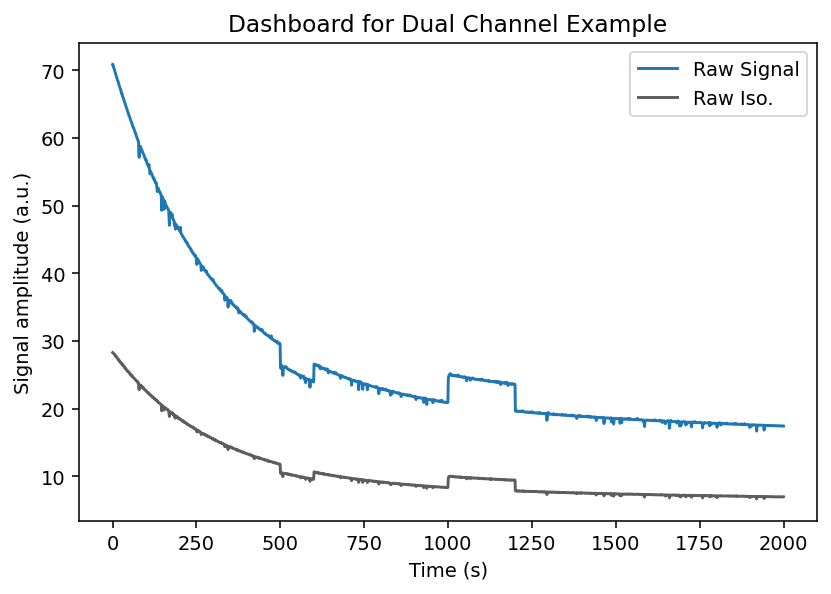

In [6]:
fig = exp.dashboard_raw()

We can see that the raw experimental and isosbestic signals have large photobleaching attenuation and movement artifacts.

Notice, however, that the movement artifacts are similar between experimental and isosbestic signals. This is why using the isosbestic as a reference channel is an effective way to correct for artifacts.

Now let's process the signal using the ``.preprocess_signal()`` methods. This method will:
* Apply a low-pass [butterworth filter](https://en.wikipedia.org/wiki/Butterworth_filter) with a specified cutoff frequency and order

* Fit the isosbestic to the experimental signal using a customizable method

* Apply the isosbestic correction

In [7]:
exp.preprocess_signal(
    # lowpass butterworth params
    cutoff_frequency=3,
    order=4,

    # correction method and isosbestic fit params
    correction_method='dF/F',
    fit_using='IRLS',
    maxiter=1000,
    c=2,

    # artifact correction params (mostly useful for single channel experiments)
    artifact_detector=None,
    artifact_corrector=None,
)

Now lets examine the full trace with the ``.dashboard_full()`` method.

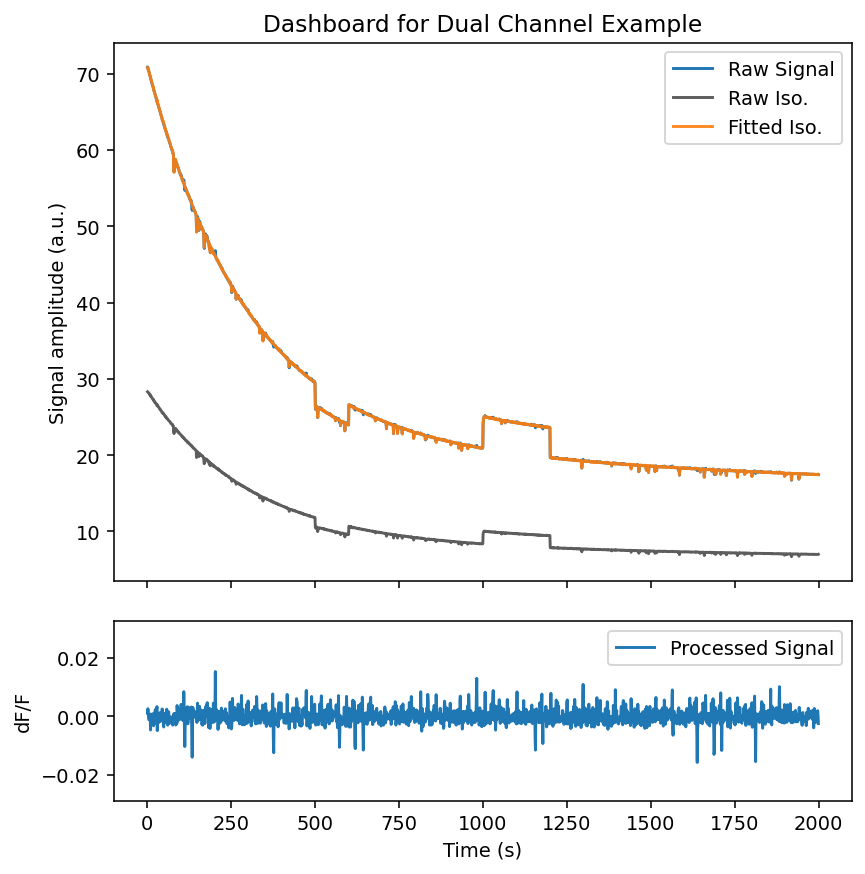

In [8]:
fig = exp.dashboard_full()

We can see that:

* The fitted isosbestic overlaps very nicely with the experimental signal

* The processed signal is free of photobleaching attenuation and movement artifacts

It is very important to note that the ``dF`` correction method does not correct for photobleaching attenuation on its own tlike the ``dF/F`` method. However, this can be fixed by trial-wise normalization later. See the example below and note the attenuation of peak and noise magnitude.

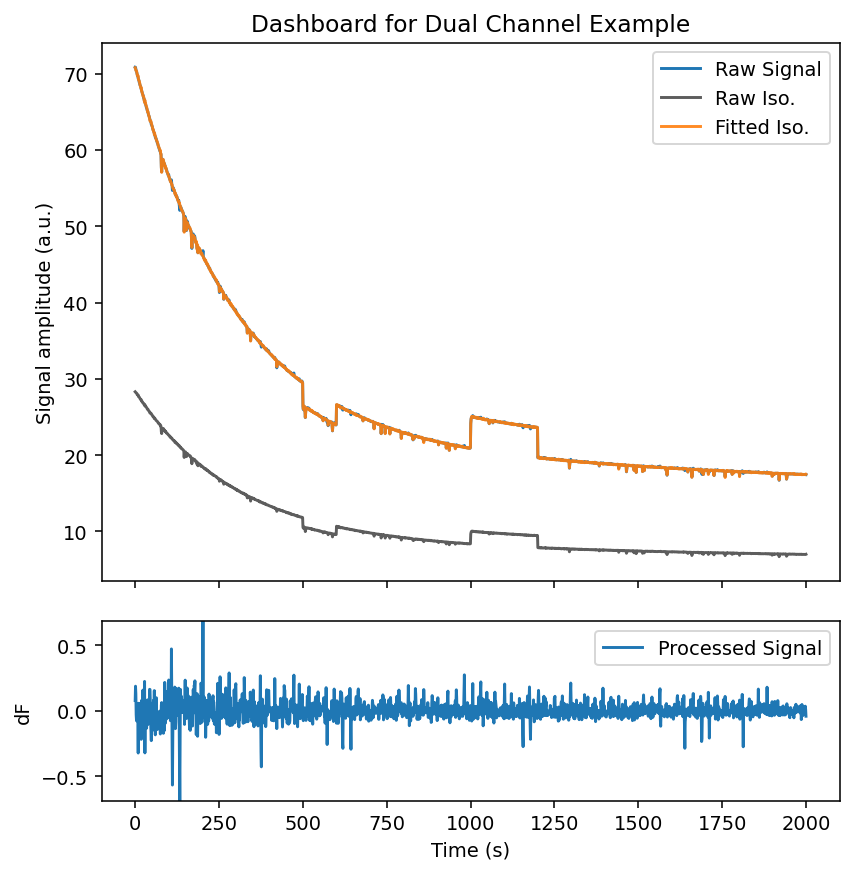

In [9]:
exp.preprocess_signal(
    # lowpass butterworth params
    cutoff_frequency=3,
    order=4,

    # correction method and isosbestic fit params
    correction_method='dF',
    fit_using='IRLS',
    maxiter=1000,
    c=2,
)
fig = exp.dashboard_full()

## Example 2.2: single channel

The general scheme for processing a **single channel** experiment is:

1. Apply a low-pass filter to both the experimental signal to filter out high frequency noise.

2. Fit a photobleaching curve to the experimental signal.
    * This package uses a negative biexponential equation to model photobleaching: $\quad \alpha_1 \exp(\beta_1 t )+ \alpha_2 \exp(\beta_2 t)$

3. Apply an reference correction either ``dB/B`` or ``dB``.
    * ``'dB/B'`` = (signal - fitted bleaching) / fitted bleaching
    * ``'dB'`` = (signal - fitted bleaching)

4. Detect and correct artifacts.
    * Since a reference isosbestic curve that shares artifacts is not present manual artifact detection and correction is required

We will begin by loading our example experiment like in [Example 1.1](#example-11-importing-from-csv), but we will not load the isosbestic trace. Notice how our dashboard plot only contains the raw experimental signal.

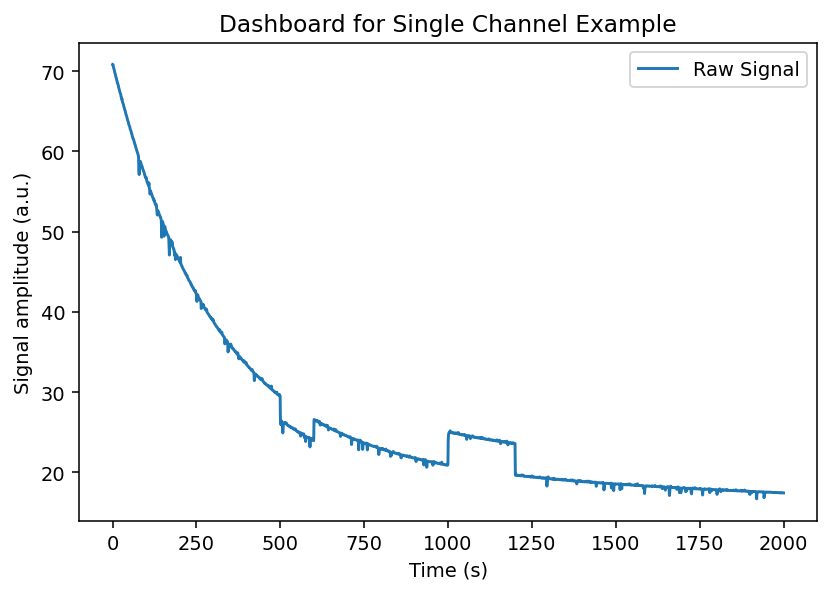

In [10]:
loader = CSVLoader(
    csv='./data/example_signals.csv',
    events_json='./data/example_events.json',
    time_col='time',
    signal_col='signal',
    isosbestic_col=None, # do not load isosbestic
    downsample=1,
)

exp = loader.load()
exp.id = 'Single Channel Example'
fig = exp.dashboard_raw()

First let's try processing the experiment without artifact correction to see what we are dealing with.

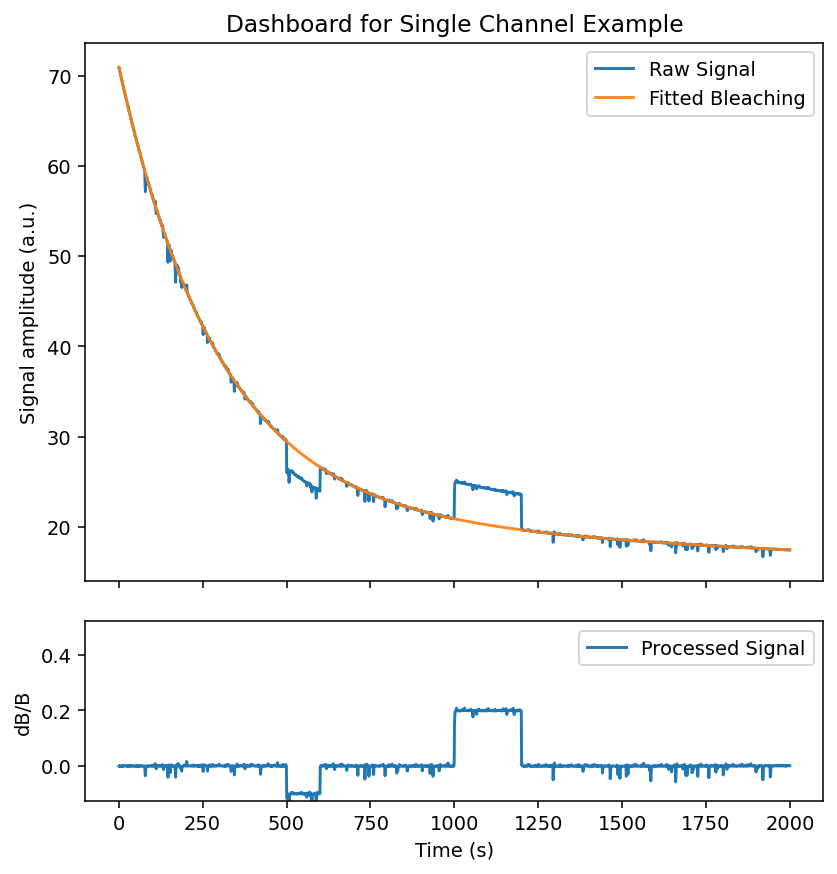

In [11]:
exp.preprocess_signal(
    # lowpass butterworth params
    cutoff_frequency=3,
    order=4,

    # correction method and isosbestic fit params
    correction_method='dB/B',
    fit_using='IRLS',
    maxiter=1000,
    c=2,
)
fig = exp.dashboard_full()

Our photobleaching curve fit very well. However, our processed signal still contains major artifacts - most prominently two large jump artifacts.

To correct those artifacts, we need to setup our artifact handlers from the analysis.artifact module. The two most common types of artifacts are:
* Spike artifacts, sharp pings that readily return to baseline

* Jump artifacts, sharp changes that change the baseline value of signal for an extended period

Below we will use a detector the uses outlier derivative score-based detection and a corrector that fills artifacts with a spline interpolator.

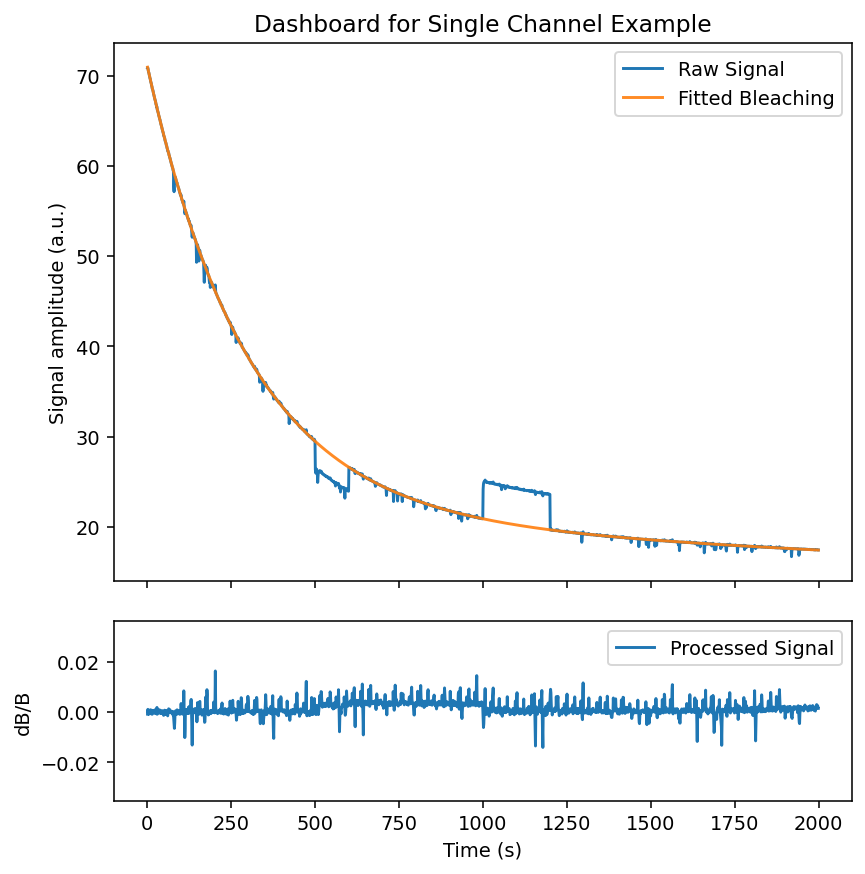

In [ ]:
# import artifact handlers
from pyFiberPhotometry.analysis.artifact import ODS_Detector, Spline_Corrector

# instantiate artifact detector and corrector
detector = ODS_Detector(
    score_threshold=5,
    jump_score_threshold=10,
    expand_sec=(0.5, 2),
    buffer_sec=1.5,
    n_chunks=20,
)

corrector = Spline_Corrector(
    anchor_sec=(0.2, 0.2),
    correct_spikes=True,
    correct_jumps=True,
)

exp.preprocess_signal(
    # lowpass butterworth params
    cutoff_frequency=3,
    order=4,

    # correction method and isosbestic fit params
    correction_method='dB/B',
    fit_using='IRLS',
    maxiter=1000,
    c=2,

    # pass in our artifact handlers
    artifact_detector=detector,
    artifact_corrector=corrector,
)

fig = exp.dashboard_full()

We can see the recovered signal with artifact correction has much less artifacting. The example used contains a lot of movement artifacts overlapping with true signal, so the manual artifact correction is not perfect. This is generally why an isosbestic reference signal is preferred.

# 3. Trial Extraction

Once we have our processed artifact-free (hopefully) signal, the next step is to slice it into many trials.

First we will start by reloading and processing our data and inspecting the events present.

In [13]:
loader = CSVLoader(
    csv='./data/example_signals.csv',
    events_json='./data/example_events.json',
    time_col='time',
    signal_col='signal',
    isosbestic_col='isosbestic',
    downsample=1,
)

exp = loader.load()
exp.id = 'Trial Extraction Example'

exp.preprocess_signal(
    cutoff_frequency=3,
    order=4,
    correction_method='dF/F',
    fit_using='IRLS',
    maxiter=1000,
    c=2,
)

exp.events.keys()

dict_keys(['event', 'lever1', 'lever2', 'loud_noise', 'no_loud_noise'])

This simulated dataset models a behavioral experiment wherein:
* The "event" event signifies the beginning of trial

* Then the rat has between 2 - 10 seconds after the "event" to choose 1 of 2 levers

* "lever1" gives the rat a small food reward

* "lever2" gives the rat a large food reward but there is a chance of a loud noise sounding immediately after given by the "loud_noise" event

Below we use the method ``.extract_trial_data()`` to extract the trial-wise data.

In [14]:
exp.extract_trial_data(
    # what event should we consider the "start" of a trial
    align_to='event',

    # what events within a trial do we want to center on
    center_on=['lever1', 'lever2'],

    # how long in seconds should our trials be relative to "center_on"
    trial_bounds=(-10, 10),

    # expected range of our events relative to "align_to"
    event_tolerences={
        'lever1':(2, 10),
        'lever2':(2, 10),
        'loud_noise':(2, 12),
    },

    # which trial-wise normalization should be preformed
    trial_normalization='none',

    # if multiple of the same event are within tolerences which should be picked
    event_conflict_logic='first',

    # should an error be thrown if multiple "center_on" event are present in the same trial
    check_overlap=True,
)

trials = exp.trial_data

Our trial-wise data is now held in ``exp.trial_data`` as a ``PhotometryData`` object!

# 4. Trial-wise Data

After processing and extracting our data, we store the resulting trial-wise information in a ``PhotometryData`` object that uses [anndata](https://github.com/scverse/anndata) as the underlying data structure. This object can be written to and read from the .h5ad format and has many useful functions for data handling and analysis. It can also hold the trial-wise data from many experiments.

First, let's load and examine our trial-wise data using ``.read_h5ad()`` and ``.print_info()``, respectively.

In [15]:
trials = PhotometryData.read_h5ad('data/example_trials.h5ad')
trials.print_info()

Photometry dataset with 75 trials, 400 timepoints, and 4 observations


The main attributes of a ``PhotometryData`` object are:

* ``.obs`` a pandas DataFrame holding trial-wise metadata (i.e. subject, event timestamps)

* ``.X`` a 2D numpy array holding the processed signals of each trial (of shape n_trials, n_times)

* ``.ts`` a 1D numpy array of the time series

Let's examine these attributes below. Notes that the event timestamp present in the experiment automatically populate ``.obs``, with ``NaN`` values corresponding to the event being abscent.

In [16]:
trials.obs.head(5)

,event,lever1,lever2,loud_noise
0,-7.443100,NaN,0.0,1.698929
1,-4.872989,NaN,0.0,1.531428
2,-5.034446,0.0,NaN,NaN
3,-3.243602,NaN,0.0,NaN
4,-3.999289,NaN,0.0,NaN


In [17]:
display(
    trials.ts[:10],     # time series
    trials.X[:2, :10],  # trial signals
    trials.X.shape,     # of shape (n_trials, n_times)
)

array([-10.        ,  -9.95000125,  -9.9000025 ,  -9.85000375,
        -9.800005  ,  -9.75000625,  -9.7000075 ,  -9.65000875,
        -9.60001   ,  -9.55001125])

array([[-0.00382377, -0.00439613, -0.00448877, -0.00346396, -0.00094471,
         0.00227785,  0.00418489,  0.00288814, -0.00151776, -0.00652179],
       [ 0.00029456,  0.00039054,  0.00078634,  0.00175338,  0.00277633,
         0.00305436,  0.00220401,  0.00064547, -0.00057243, -0.00051564]],
      dtype=float32)

(75, 400)

Manipulating and analyzing data often requires the manipulation of ``.obs``. For an example, let's catagorize each trial outcome into 4 catagories and add this label to ``.obs``.

* ``NoResponse`` corresponds to the subject failing to choose a lever

* ``type1`` corresponds to the subject choosing the small reward lever

* ``type2`` corresponds to the subject choosing the large reward lever but NOT recieving a loud noise

* ``type3`` corresponds to the subject choosing the large reward lever AND recieving a loud noise

In [18]:
def label_trials(df: pd.DataFrame) -> pd.DataFrame:
    # label trial outcome by event presense
    has_l1 = ~df['lever1'].isna()
    has_l2 = ~df['lever2'].isna()
    has_ln = ~df['loud_noise'].isna()

    df['trial_label'] = pd.NA
    df.loc[has_l1, 'trial_label'] = 'type1'
    df.loc[has_l2 & ~has_ln, 'trial_label'] = 'type2'
    df.loc[has_l2 & has_ln, 'trial_label'] = 'type3'
    df.loc[~has_l1 & ~has_l2, 'trial_label'] = 'NoResponse'
    return df

trials.obs = label_trials(trials.obs)
trials.obs.head(5)

,event,lever1,lever2,loud_noise,trial_label
0,-7.443100,NaN,0.0,1.698929,type3
1,-4.872989,NaN,0.0,1.531428,type3
2,-5.034446,0.0,NaN,NaN,type1
3,-3.243602,NaN,0.0,NaN,type2
4,-3.999289,NaN,0.0,NaN,type2


Now that we have the trials labeled, let's graph the trial signals using ``.plot_all()`` and ``.plot_groups()``.

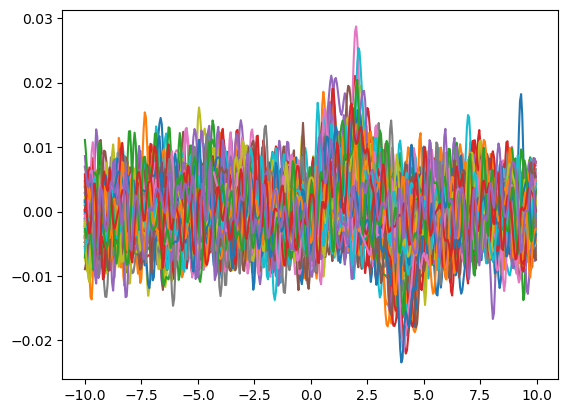

In [19]:
trials.plot_all()

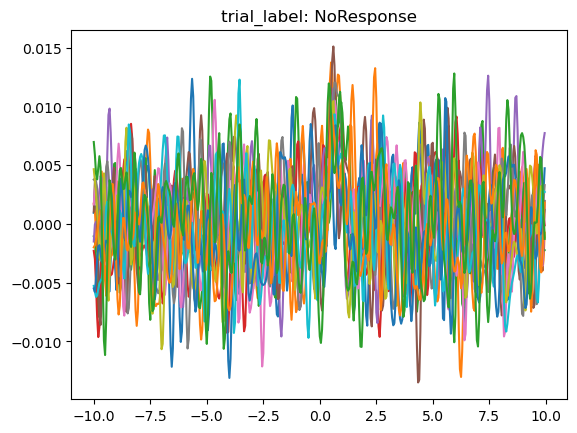

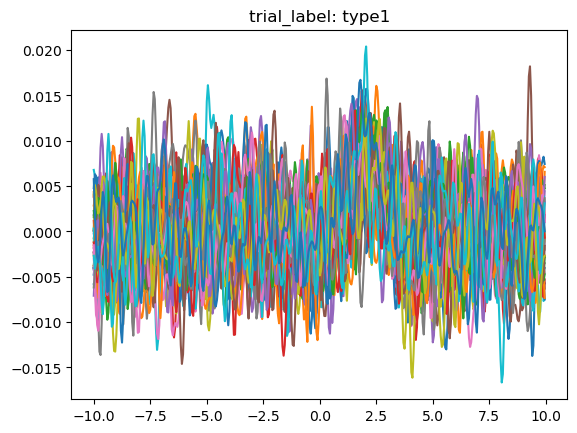

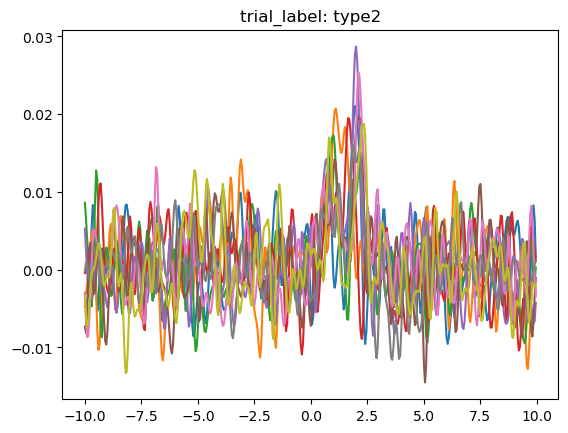

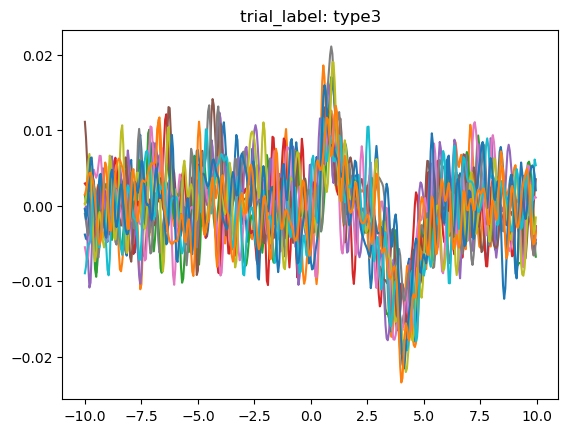

In [20]:
trials.plot_groups(
    group_on=['trial_label']
)

We can clearly see that the different trial outcomes have different signal architectures.

We can dig deeper into this difference by calculating and comparing a summary metric, like area under the curve, by using ``.area_under_curve()``.

In [21]:
# calculate the area under the curve from 0 to 6.5 seconds and save the results to .obs
trials.obs['AUC'] = trials.area_under_curve(
    centers=0,
    bounds=(0, 6.5),
)

trials.obs.head(5)

,event,lever1,lever2,loud_noise,trial_label,AUC
0,-7.443100,NaN,0.0,1.698929,type3,-0.004555
1,-4.872989,NaN,0.0,1.531428,type3,-0.019820
2,-5.034446,0.0,NaN,NaN,type1,0.012064
3,-3.243602,NaN,0.0,NaN,type2,0.012603
4,-3.999289,NaN,0.0,NaN,type2,0.025481


<Axes: xlabel='trial_label', ylabel='AUC'>

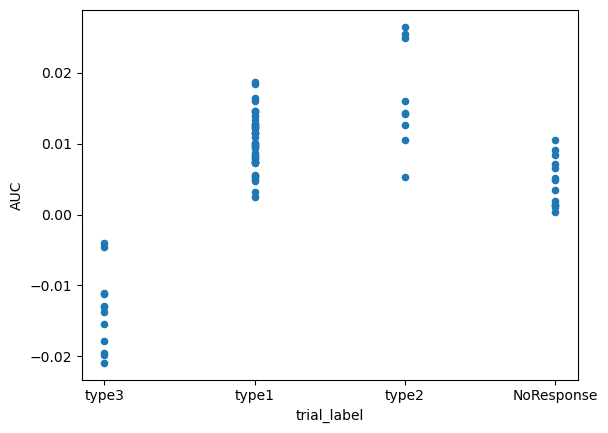

In [22]:
# quick plot using pandas to compare differences
trials.obs.plot(
    x='trial_label',
    y='AUC',
    kind='scatter',
)

``PhotometryData`` also provides methods to filter out specific trials and average across groups.

We can pass a boolean mask or a sequence of numeric indexes to ``.filter_rows()`` to select the desired trials.

In [23]:
# filter trials using indexes or a boolean mask
filt_trials = trials.filter_rows(
    trials.obs['trial_label'] != 'NoResponse',
)

Using the ``.collapse()`` method we can easily aggregate data over groups while calculating distribution metrics and applying both to the desired data in ``.obs``.

In [24]:
avg = filt_trials.collapse(
    group_on=['trial_label'],
    metrics={'std' : np.std},
    data_cols=['event', 'AUC'],
    count_col='n_trials',
)

avg.obs.head(5)

,trial_label,n_trials,event,AUC,event_std,AUC_std
0,type3,12,-5.556544,-0.013656,1.387726,0.005289
1,type1,41,-5.187139,0.010299,1.458783,0.003876
2,type2,9,-4.969250,0.016676,1.186388,0.006965


Now we can plot the average signal for each trial type, with labels and error bars.

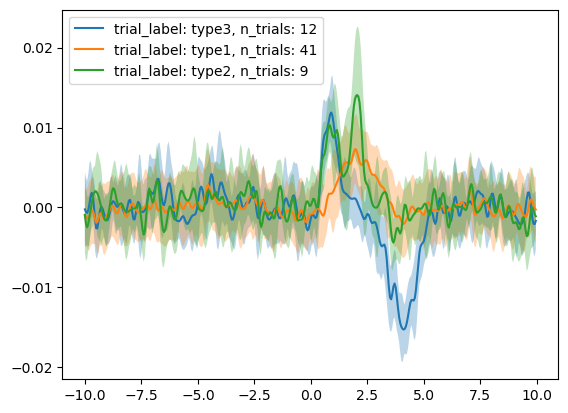

In [25]:
avg.plot_all(
    label_with=['trial_label', 'n_trials'],
    err_layer='std',
)

The passed "metrics" in ``.collapse()`` are stored in the layers of the underlying anndata structure and are of the same shape as ``.X``. We can use the ``.get_layer()`` function to easily fetch them.

In [26]:
avg.get_layer('std')[:2, :10]

array([[0.00467339, 0.00430025, 0.00399998, 0.00454216, 0.00510952,
        0.00458797, 0.00310368, 0.00250425, 0.00341994, 0.00388657],
       [0.00336808, 0.00344267, 0.00370813, 0.00412086, 0.004291  ,
        0.00417641, 0.00417782, 0.00415593, 0.00369951, 0.00307086]],
      dtype=float32)

What if we want to refocus on the subject's response to the trial start queue ("event" in this case)? We can do this with the ``.window()`` method. 

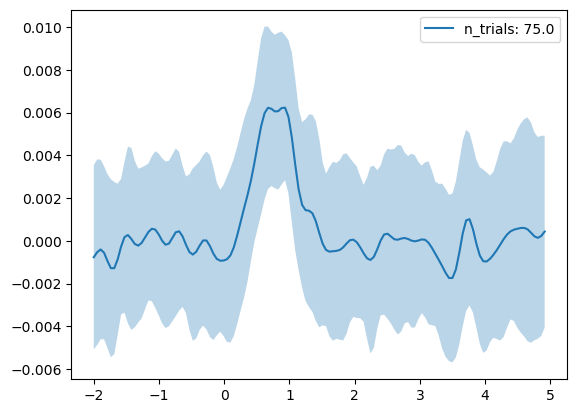

In [27]:
recentered = trials.window(
    centers = trials.obs['event'], # you can pass in a scalar or a sequence of timestamps
    bounds = (-2, 5),
    event_cols=['event', 'lever1', 'lever2', 'loud_noise'] # which columns in .obs to also recenter
)

start_avg = recentered.collapse(
    group_on=None, # pass None to average all the trials
    metrics={'std' : np.std},
    data_cols=['lever1', 'lever2'],
    count_col='n_trials',
)

start_avg.plot_all(
    label_with=['n_trials'], 
    err_layer='std',
)

# 5. Extending Functionality

``pyFiberPhotometry`` has been built with extendability in mind. Each of the three core processing modules, ``PhotometryLoader``, ``PhotometryExperiment``, and ``PhotometryData`` can easily be subclassed to provide customized functionality. For bulk-processing many experiments of the same general type subclassing can be incredibly useful.

If you do not have a ton of coding experience, writing your own custom classes can seem intimidating. However, a lot of the difficult parts of processing are already implemented in class methods you just have to wire them together.

First let's go over how to subclass ``PhotometryExperiment`` and why you might want to.

Let's say I have ~1,000 experiments all stored in TDT vaults. With a subclass I can make the ``CustomExperiment`` constructor directly read from the TDT vaults. I can also implement functionality to label trials and create a single function pipeline method called ``.run_pipeline()``.

In [28]:
from pyFiberPhotometry import PhotometryExperiment

class CustomExperiment(PhotometryExperiment):
    def __init__(
        self,
        data_folder: str,
        box: str = "A",
        event_labels: list[str] = ("Lrg", "Sml", "Hsl", "Zap"),
        signal_label: str = "_465",
        isosbestic_label: str = "_405",
        downsample: int = 10,
        ):
        """
        Initialize an CustomExperiment from TDT data.
        Args:
            data_folder (str): Path to the TDT block folder.
            box (str): TDT box identifier.
            event_labels (list[str]): Event labels to extract for RDT.
            signal_label (str): Base label for the signal stream.
            isosbestic_label (str): Base label for the isosbestic stream.
        """
        # load from TDT format
        loader = TDTLoader(data_folder, box, event_labels, signal_label, isosbestic_label, downsample)
        data = loader.extract_data()
        super().__init__(**data)

    def label_trials(self):
        self.trial_data.obs['label'] = 'type5'

    def run_pipeline(self):
        self.preprocess_signal(
            iso_correction_method='dF',
            fit_using='IRLS_no_intercept',
        )
        self.extract_trial_data(
            align_to='some_event',
            center_on=['some_event'],
            trial_normalization='zscore',
        )
        self.label_trials()

Second let's go over how to write your own custom loader. Because this package is still in its early stages, not many formats are nativly supported.

All a loader class needs is:

1. A constructor (``.__init__()``) that takes in a save all the params

2. ``.extract_data()`` that takes in no arguements and returns a dictionary of the key-value pairs found in the ``PhotometryExperiment`` constructor

3. ``.load()`` that take in no arguements and returns a ``PhotometryExperiment`` object by passing in the ``.extract_data()`` output into ``PhotometryExperiment``'s constructor

In [29]:
from pyFiberPhotometry import PhotometryLoader

class CustomLoader(PhotometryLoader):
    def __init__(self, path_to_table: str, path_to_events: str) -> None:
        self.file = path_to_table
        self.event_file = path_to_events

    def extract_data(self) -> dict:
        table = pd.read_excel(self.file)
        event_table = pd.read_csv(self.event_file)

        data = dict(
            raw_signal = table['signal'],
            raw_isosbestic = None,
            time = table['time'],
            events = {
                'event' : event_table['event']
            }
        )
        return data
    
    def load(self) -> PhotometryExperiment:
        data = self.extract_data()
        return PhotometryExperiment(**data)

# 6. Bulk Processing

One of the major uses of this package is bulk processing. Below is an example of a bulk processing function using ``CustomExperiment``. The general scheme for any bulk processing function is largely the same.

In [30]:
import os

def process_whole_directory(
    data_dir: str,
    output_h5ad: str,

    boxes: list[str] = ['A', 'B'],
    event_labels: list[str] = ('Lrg', 'Sml', 'Hsl', 'Zap'),
    signal_label: str = '_465',
    isosbestic_label: str = '_405',
    ) -> None:

    # create list of tdt data folders, ignore non-directories
    tdt_folders_list = [os.path.join(data_dir, foldername) for foldername in os.listdir(data_dir)]
    tdt_folders_list = [folderpath for folderpath in tdt_folders_list if not os.path.isfile(folderpath)]

    trials = None

    # loop through every TDT folder and box
    for tdt_folder in tdt_folders_list:
        for box in boxes:
            # a try-except block can be very useful so the pipeline does not stop from a single error
            try:
                exp = CustomExperiment(
                    tdt_folder,
                    box=box,
                    event_labels=event_labels,
                    signal_label=signal_label,
                    isosbestic_label=isosbestic_label,
                )

                exp.run_pipeline()

                if trials is None:
                    trials = exp.trial_data
                else:
                    trials.combine_obj(exp.trial_data)

            except Exception as e:
                print(f"Error processing {tdt_folder}, box {box}: {e}")
            
    trials.write_h5ad(output_h5ad)